In [ ]:
# My project is investigating which U.S. states and counties exhibit the greatest disparities
#in environmental burden, and whether these disparities align with widely-held perceptions
#and empirical patterns of environmental racism.

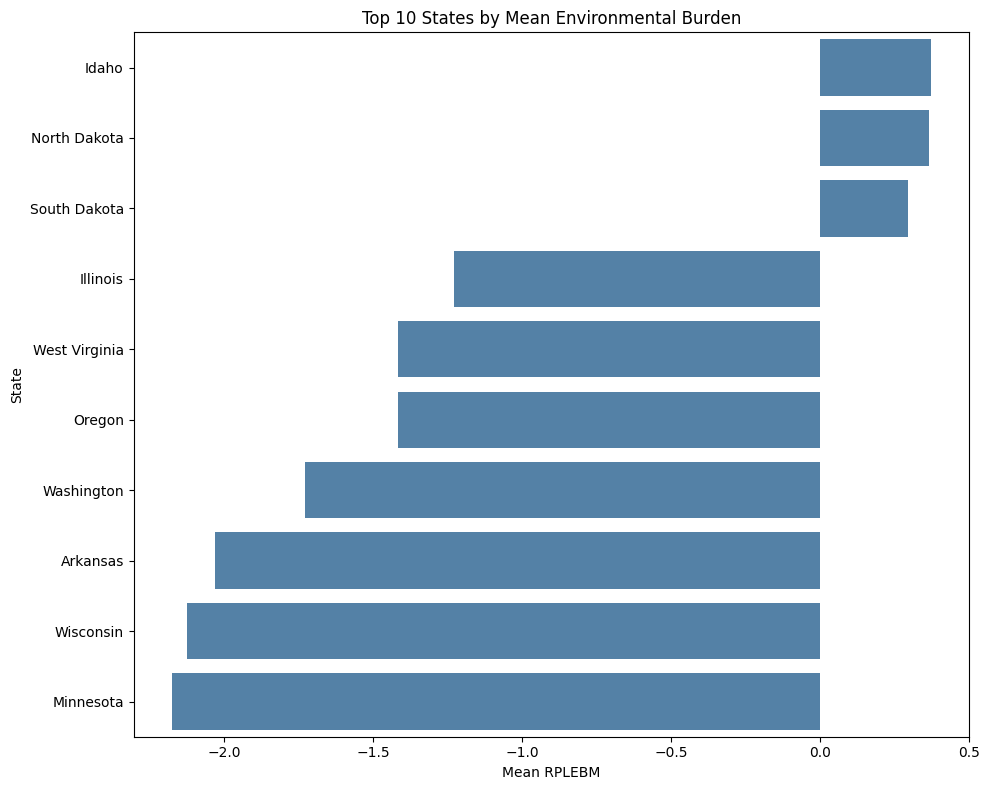

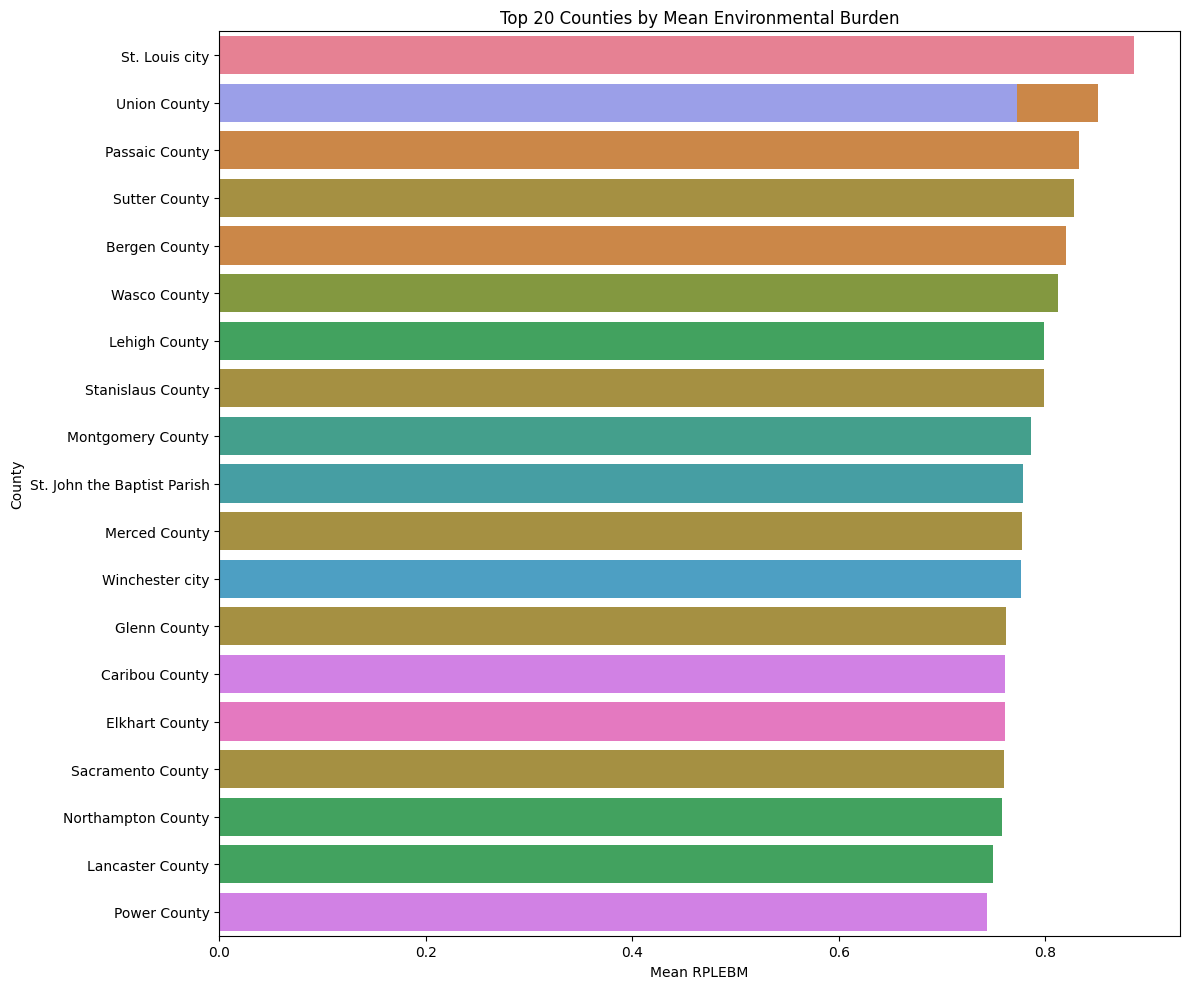

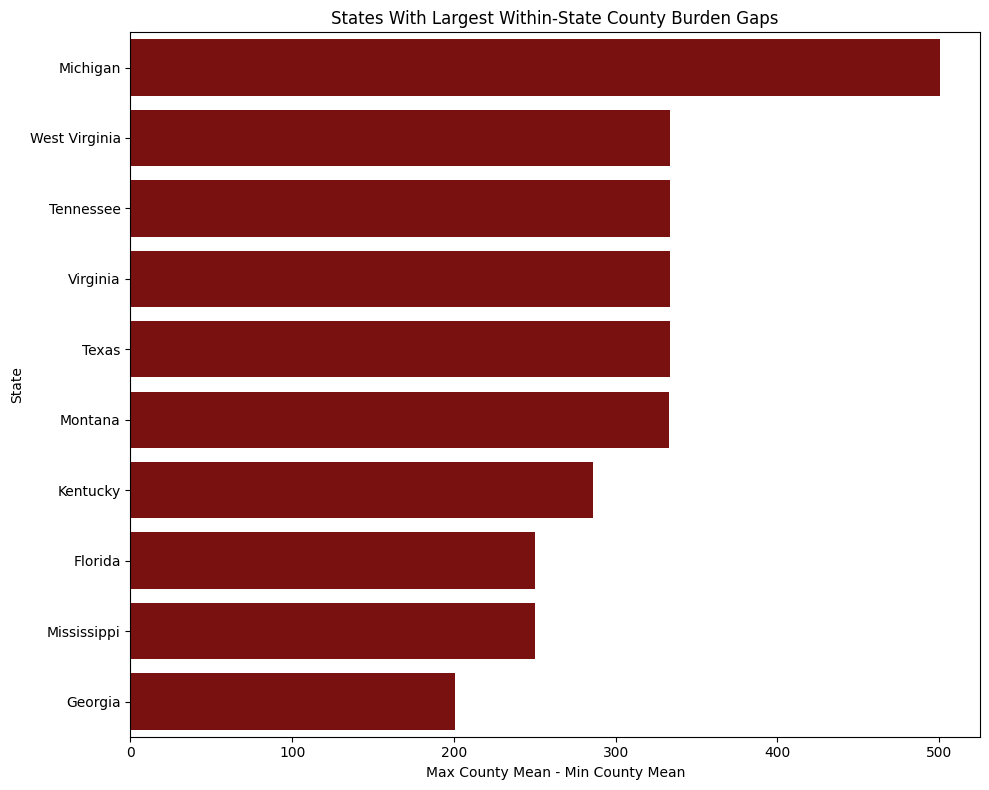

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/obedfrimpong/Desktop/qss-20-final-project/data/EJI_2024_United_States.csv")


df["RPL_EBM"] = pd.to_numeric(df["RPL_EBM"], errors="coerce")

state_col = "StateDesc" if "StateDesc" in df.columns else None
county_col = None
for candidate in ["COUNTY", "CountyDesc", "County", "CountyNameDesc"]:
    if candidate in df.columns:
        county_col = candidate
        break

df = df.dropna(subset=["RPL_EBM"])

# State-level summary
state_summary = (
    df.groupby(state_col)["RPL_EBM"]
    .agg(["mean", "median", "std", "min", "max", "count"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

state_summary["range"] = state_summary["max"] - state_summary["min"]

# County-level summary
if county_col is not None:
    county_summary = (
        df.groupby([state_col, county_col])["RPL_EBM"]
        .agg(["mean", "median", "std", "min", "max", "count"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

    county_summary["range"] = county_summary["max"] - county_summary["min"]

    # Largest within-state county disparities
    county_dispersion = (
        county_summary.groupby(state_col)["mean"]
        .agg(["min", "max", "mean", "count"])
        .reset_index()
    )
    county_dispersion["within_state_gap"] = county_dispersion["max"] - county_dispersion["min"]
    county_dispersion = county_dispersion.sort_values("within_state_gap", ascending=False)

# Demographic pattern checks
demo_candidates = {
    "pct_black": ["PCTBLACK", "BlackPct", "PctBlack"],
    "pct_hispanic": ["PCTHISP", "HispanicPct", "PctHispanic"],
    "pct_poverty": ["PCTPOV", "PovertyPct", "PctPoverty"],
    "pct_white": ["PCTWHITE", "WhitePct", "PctWhite"],
    "pct_asian": ["PCTASIAN", "AsianPct", "PctAsian"],
}

found_demo_cols = {}
for key, candidates in demo_candidates.items():
    for c in candidates:
        if c in df.columns:
            found_demo_cols[key] = c
            break

corr_results = {}
for key, col in found_demo_cols.items():
    df[col] = pd.to_numeric(df[col], errors="coerce")
    corr_results[key] = df[["RPL_EBM", col]].corr().iloc[0, 1]

corr_df = pd.DataFrame(
    [{"variable": k, "column": v, "correlation_with_burden": corr_results[k]} for k, v in found_demo_cols.items()]
)

# Identify top places
top_states = state_summary.head(10)

top_counties = None
if county_col is not None:
    top_counties = county_summary.head(20)


state_summary.to_csv("state_burden_summary.csv", index=False)
corr_df.to_csv("burden_demographic_correlations.csv", index=False)

if county_col is not None:
    county_summary.to_csv("county_burden_summary.csv", index=False)
    county_dispersion.to_csv("within_state_county_disparities.csv", index=False)

# Plots
plt.figure(figsize=(10, 8))
sns.barplot(data=top_states, y=state_col, x="mean", color="steelblue")
plt.title("Top 10 States by Mean Environmental Burden")
plt.xlabel("Mean RPLEBM")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("top_states_burden.png", dpi=300)
plt.show()

if county_col is not None:
    plt.figure(figsize=(12, 10))
    sns.barplot(data=top_counties, y=county_col, x="mean", hue=state_col, dodge=False)
    plt.title("Top 20 Counties by Mean Environmental Burden")
    plt.xlabel("Mean RPLEBM")
    plt.ylabel("County")
    plt.legend([], [], frameon=False)
    plt.tight_layout()
    plt.savefig("top_counties_burden.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 8))
    sns.barplot(data=county_dispersion.head(10), y=state_col, x="within_state_gap", color="darkred")
    plt.title("States With Largest Within-State County Burden Gaps")
    plt.xlabel("Max County Mean - Min County Mean")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig("state_county_disparity_gaps.png", dpi=300)
    plt.show()